1. KÜTÜPHANELERİN İÇE AKTARILMASI (IMPORTS):
Bu bölümde, projemizde kullanacağımız araçları projemize dahil ediyoruz.

In [3]:
import os # Bilgisayardaki dosya ve klasör yollarını kontrol etmek için.
import matplotlib.pyplot as plt # Modelin başarısını çizgi grafiklerle göstermek için.
import numpy as np # Üretilen tahmin sonuçları üzerinde matematiksel/dizi işlemleri yapmak için.
import tensorflow as tf # Derin öğrenme mimarimizi kurduğumuz ana kütüphanemiz.
from tensorflow.keras import layers, models, applications # Katmanları ve önceden eğitilmiş modelleri almak için.
from sklearn.metrics import classification_report, confusion_matrix # Başarı metriklerini ve hata raporunu oluşturmak için.
import seaborn as sns # Hata matrisini renkli bir tablo (heatmap) olarak çizdirmek için.

2. VERİ SETİNİN İNDİRİLMESİ VE HAZIRLANMASI:
Çiçek veri setini internetten indirip eğitim ve test olarak ikiye ayırıyoruz.

In [4]:
# TensorFlow'un sunduğu örnek çiçek veri setinin adresini belirtiyor ve arşivden çıkarıyoruz.
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

# KLASÖR DÜZELTMESİ: Arşivden çıkan dosya "flower_photos/flower_photos" gibi iç içe 
# geçmişse, ana dizini doğru ayarlıyoruz ki model 5 farklı sınıfı (papatya, gül vb.) görebilsin.
if os.path.exists(os.path.join(data_dir, 'flower_photos')):
    data_dir = os.path.join(data_dir, 'flower_photos')

# Fotoğrafların yeniden boyutlandırılacağı standart ölçüyü (160x160) ve 
# modelin tek seferde okuyacağı fotoğraf sayısını (32) belirliyoruz.
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

# Veri setinin %80'ini modelin öğrenmesi (training) için ayırıyoruz.
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

# Veri setinin kalan %20'sini modelin kendini test etmesi (validation) için ayırıyoruz.
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

# Bulunan sınıf isimlerini ve toplam sınıf sayısını ekrana yazdırıyoruz.
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nSınıf Sayısı: {num_classes} - Sınıflar: {class_names}")

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.

Sınıf Sayısı: 5 - Sınıflar: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


3. MODEL MİMARİSİNİN KURULMASI (TRANSFER LEARNING):
Google'ın daha önce eğittiği MobileNetV2 modelini alıp kendi çiçeklerimize uyarlıyoruz.

In [5]:
# Önceden eğitilmiş temel modeli (base_model) indiriyoruz. 'include_top=False' diyerek
# orijinal karar verme kısmını atıp kendi çiçek katmanımızı eklemek üzere hazırlarız.
base_model = applications.MobileNetV2(input_shape=IMG_SIZE + (3,),
                                      include_top=False, weights='imagenet')

# Temel modelin daha önceden öğrendiği yetenekler (kenar, renk tanıma) bozulmasın diye 
# mevcut ağırlıkları donduruyoruz. Sadece kendi ekleyeceğimiz son katman eğitilecek.
base_model.trainable = False 

# AKTİVASYON VE LOSS SEÇİMİ:
# Eğer 2 sınıf (kedi-köpek vb.) varsa binary (ikili) algoritmalar kullanılır.
# Eğer 5 sınıf (çiçekler gibi) varsa multiclass (çoklu) algoritmalar kullanılır.
if num_classes == 2:
    output_units = 1
    activation_fn = 'sigmoid' # İkili sınıflandırma için sigmoid
    loss_fn = 'binary_crossentropy'
else:
    output_units = num_classes
    activation_fn = 'softmax' # Çoklu sınıflandırma için softmax
    loss_fn = 'sparse_categorical_crossentropy'

# Katmanları sırayla üst üste dizerek asıl yapımızı oluşturuyoruz:
model = models.Sequential([
    layers.Rescaling(1./127.5, offset=-1), # Pikselleri MobileNetV2'nin anlayacağı aralığa (-1 ile 1) çevirir.
    base_model,                            # Yukarıda indirdiğimiz dondurulmuş ana model.
    layers.GlobalAveragePooling2D(),       # Gelen karmaşık verileri düzleştirip özetler.
    layers.Dropout(0.2),                   # Model ezberlemesin diye nöronların %20'sini rastgele uyutur.
    layers.Dense(output_units, activation=activation_fn) # Çiçeğin türüne karar veren son katman.
])

# Modelin öğrenme yöntemini (adam) ve başarısını neyle ölçeceğini (accuracy) ayarlayıp derliyoruz.
model.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])
model.summary() # Modelin özetini (katmanları ve parametre sayısını) ekrana basar.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

4. MODEL EĞİTİMİ:
Modelin eğitim verilerini görerek öğrenmeye başladığı aşama.

In [6]:
# Eğitim turu (epoch) sayısı. Model tüm çiçekleri 5 kere baştan sona görecek.
epochs = 5 
print("\nEğitim Başlıyor...")

# Öğrenme işlemini başlatıyoruz. Model 'train_ds' ile öğrenir, 'val_ds' ile test edilir.
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)


Eğitim Başlıyor...
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 157ms/step - accuracy: 0.7115 - loss: 0.8011 - val_accuracy: 0.8529 - val_loss: 0.4527
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.8658 - loss: 0.3918 - val_accuracy: 0.8719 - val_loss: 0.3833
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - accuracy: 0.8951 - loss: 0.3088 - val_accuracy: 0.8828 - val_loss: 0.3484
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.9043 - loss: 0.2669 - val_accuracy: 0.8856 - val_loss: 0.3401
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - accuracy: 0.9193 - loss: 0.2268 - val_accuracy: 0.8869 - val_loss: 0.3336


5. SONUÇLARIN GÖRSELLEŞTİRİLMESİ VE ANALİZİ:
Eğitim bittikten sonra modelin başarısını ve yaptığı hataları grafiklerle inceliyoruz.


--- SINIFLANDIRMA RAPORU ---
              precision    recall  f1-score   support

       daisy       0.91      0.84      0.88       129
   dandelion       0.93      0.90      0.92       176
       roses       0.86      0.90      0.88       120
  sunflowers       0.88      0.91      0.90       152
      tulips       0.85      0.87      0.86       157

    accuracy                           0.89       734
   macro avg       0.89      0.89      0.89       734
weighted avg       0.89      0.89      0.89       734



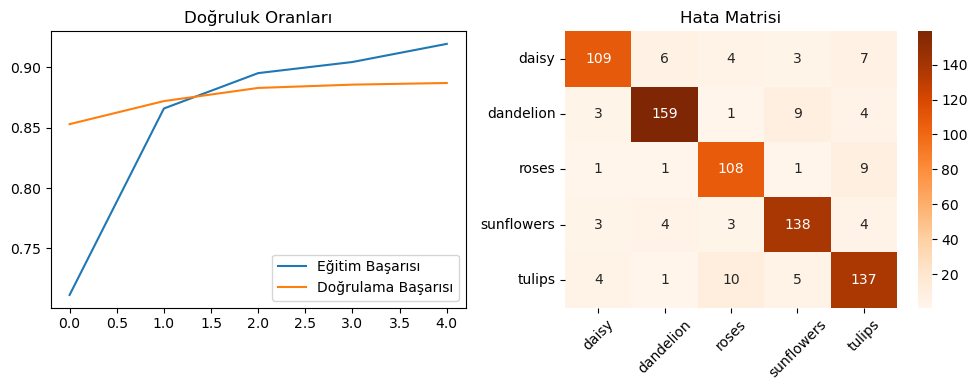

In [7]:
def plot_results(history, model, val_ds, class_names):
    # a) Eğitim Başarısı Grafiği
    acc = history.history['accuracy'] # Her turdaki eğitim başarısı
    val_acc = history.history['val_accuracy'] # Her turdaki test başarısı
    
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Eğitim Başarısı')
    plt.plot(val_acc, label='Doğrulama Başarısı')
    plt.legend()
    plt.title('Doğruluk Oranları')

    # b) Tahminlerin Alınması ve Sınıflandırma Raporu
    y_true, y_pred = [], []
    for images, labels in val_ds:
        preds = model.predict(images, verbose=0) # Ayırdığımız test resimlerini modele soruyoruz.
        y_true.extend(labels.numpy())            # Gerçek cevapları kaydediyoruz.
        
        # Modelin verdiği yüzdelik tahminleri net sonuçlara (0, 1, 2, 3, 4) çeviriyoruz.
        if len(class_names) == 2:
            y_pred.extend((preds > 0.5).astype(int).flatten())
        else:
            y_pred.extend(np.argmax(preds, axis=1))

    # Hangi çiçek türünde ne kadar başarılı olduğumuzu ekrana yazdırır.
    print("\n--- SINIFLANDIRMA RAPORU ---")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # c) Hata Matrisi (Confusion Matrix) Tablosu
    # Lale'yi Gül ile karıştırmış mı gibi spesifik hataları görmek için renkli tablo oluşturuyoruz.
    cm = confusion_matrix(y_true, y_pred)
    plt.subplot(1, 2, 2)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
    plt.title('Hata Matrisi')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Grafikleri düzgün bir düzende ekranda gösteriyoruz.
    plt.tight_layout()
    plt.show()

# Yazdığımız görselleştirme fonksiyonunu çağırarak grafikleri ekrana yansıtıyoruz.
plot_results(history, model, val_ds, class_names)